# Confusion Matrix cho Spam Model
Notebook này sẽ: cài thư viện nếu cần, train/đánh giá mô hình, vẽ confusion matrix cho train và test, rồi lưu ảnh PNG.


In [1]:
# Cài thư viện cần thiết nếu máy chưa có
!pip install pandas numpy matplotlib scikit-learn -q



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

DATA_PATH = "emails.csv"
OUTPUT_DIR = "confusion_matrices"
os.makedirs(OUTPUT_DIR, exist_ok=True)


C:\Users\ADMIN\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
def load_dataset(path):
    df = pd.read_csv(path)
    df = df.drop(columns=["Email No."])
    X = df.drop(columns=["Prediction"]).values
    y = df["Prediction"].values
    feature_names = df.drop(columns=["Prediction"]).columns.to_list()
    return X, y, feature_names

class MultinomialNaiveBayes:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_spam = np.sum(y == 1)
        n_ham = np.sum(y == 0)
        self.log_prior_spam = np.log(n_spam / n_samples)
        self.log_prior_ham = np.log(n_ham / n_samples)
        spam_words_count = np.sum(X[y == 1], axis=0)
        ham_words_count = np.sum(X[y == 0], axis=0)
        total_spam_words = np.sum(spam_words_count)
        total_ham_words = np.sum(ham_words_count)
        self.log_prob_spam = np.log((spam_words_count + 1) / (total_spam_words + n_features))
        self.log_prob_ham = np.log((ham_words_count + 1) / (total_ham_words + n_features))

    def predict(self, X):
        predictions = []
        for x in X:
            score_spam = self.log_prior_spam + np.sum(x * self.log_prob_spam)
            score_ham = self.log_prior_ham + np.sum(x * self.log_prob_ham)
            predictions.append(1 if score_spam > score_ham else 0)
        return np.array(predictions)


In [4]:
print('Đang đọc dữ liệu...')
X, y, feature_names = load_dataset(DATA_PATH)

np.random.seed(42)
indices = np.random.permutation(len(X))
train_size = int(0.8 * len(X))
train_idx, test_idx = indices[:train_size], indices[train_size:]
X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

model = MultinomialNaiveBayes()
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_acc = np.mean(train_pred == y_train)
test_acc = np.mean(test_pred == y_test)
print(f'Train accuracy: {train_acc * 100:.2f}%')
print(f'Test accuracy: {test_acc * 100:.2f}%')


Đang đọc dữ liệu...
Train accuracy: 94.85%
Test accuracy: 94.11%


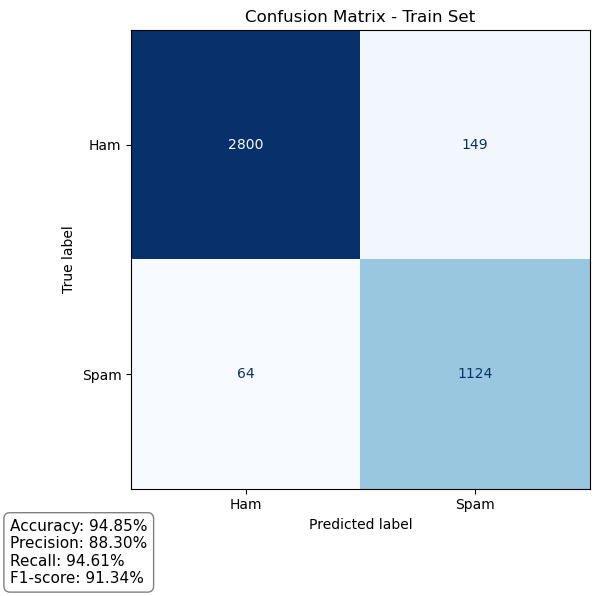

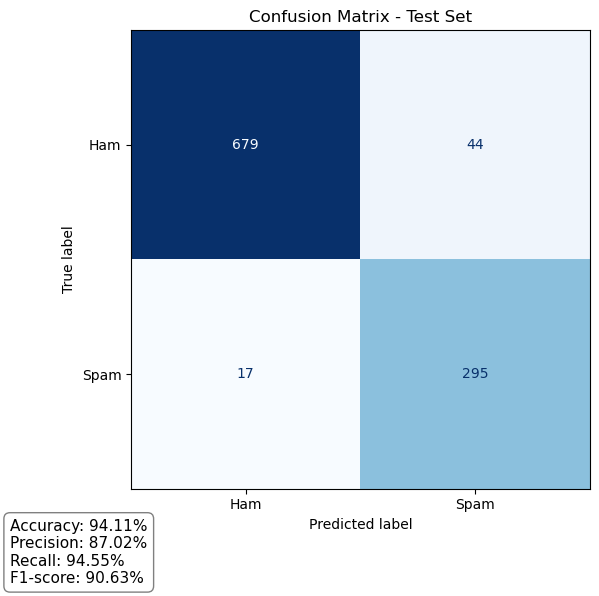

Train Metrics:
  Accuracy : 94.85%
  Precision: 88.30%
  Recall   : 94.61%
  F1-score : 91.34%
Test Metrics:
  Accuracy : 94.11%
  Precision: 87.02%
  Recall   : 94.55%
  F1-score : 90.63%
Train confusion matrix:
[[2800  149]
 [  64 1124]]
Dã lưu: confusion_matrices\confusion_matrix_train.png
Test confusion matrix:
[[679  44]
 [ 17 295]]
Dã lưu: confusion_matrices\confusion_matrix_test.png


In [5]:
def plot_and_save_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
    ax.set_title(title)

    metrics_text = (
        f'Accuracy: {acc * 100:.2f}%\n'
        f'Precision: {prec * 100:.2f}%\n'
        f'Recall: {rec * 100:.2f}%\n'
        f'F1-score: {f1 * 100:.2f}%'
    )
    fig.text(
        0.02,
        0.02,
        metrics_text,
        fontsize=11,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray')
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    output_path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return cm, output_path, acc, prec, rec, f1


def print_metrics(y_true, y_pred, split_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f'{split_name} Metrics:')
    print(f'  Accuracy : {acc * 100:.2f}%')
    print(f'  Precision: {prec * 100:.2f}%')
    print(f'  Recall   : {rec * 100:.2f}%')
    print(f'  F1-score : {f1 * 100:.2f}%')
    return acc, prec, rec, f1

train_cm, train_path, train_acc, train_prec, train_rec, train_f1 = plot_and_save_confusion_matrix(
    y_train, train_pred, 'Confusion Matrix - Train Set', 'confusion_matrix_train.png'
)
test_cm, test_path, test_acc, test_prec, test_rec, test_f1 = plot_and_save_confusion_matrix(
    y_test, test_pred, 'Confusion Matrix - Test Set', 'confusion_matrix_test.png'
)

print_metrics(y_train, train_pred, 'Train')
print_metrics(y_test, test_pred, 'Test')

print('Train confusion matrix:')
print(train_cm)
print(f'Dã lưu: {train_path}')
print('Test confusion matrix:')
print(test_cm)
print(f'Dã lưu: {test_path}')
